# Encoder-Only (Pointwise MLP) — Hyperparameter Sweep

Performs a **Hydra grid sweep** over encoder-only regularisation parameters
using SLURM for parallel training.

**Supports two data sources** (set `DATA_SOURCE` in Section 1):
- `"dysts"` — synthetic trajectories from dynamical systems (e.g. Lorenz)
- `"wmtask"` — hidden-state trajectories from a trained working memory RNN

**Key difference from the SSM/Transformer sweep:** The encoder is a **pointwise
MLP** — it applies the same MLP independently at each timestep with **no
temporal context**. All temporal information comes from the delay embedding
in the input. This avoids the double-smoothing problem where an SSM's
recurrent state integration compounds with the delay embedding's implicit
temporal averaging, compressing the Lyapunov spectrum toward zero.

**Pipeline:**
1. Set hyperparameters in clearly labelled cells (Sections 1–2)
2. Build Hydra config (single source of truth for local + sweep)
3. Generate data locally for post-hoc diagnostics
4. Check W&B for already-completed runs
5. Launch Hydra `--multirun` sweep via SLURM (one job per parameter combination)
6. Collect results and visualise

> **Wait for all SLURM jobs to finish** before running Section 7.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import itertools
import subprocess
import sys, os

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb
from hydra.utils import instantiate
from omegaconf import OmegaConf

from JacobianODE.jacobians.core import seed_everything
from JacobianODE.jacobians.data import make_trajectories, postprocess_data, create_dataloaders
from JacobianODE.jacobians.training import train_model
from JacobianODE.encoder_only.config import load_encoder_config

torch.set_float32_matmul_precision('high')
print(f'PyTorch {torch.__version__}  |  GPUs: {torch.cuda.device_count()}')

PyTorch 2.10.0+cu128  |  GPUs: 1


## 1. Hyperparameters

In [3]:
# ----------------------------------------------------------------
# Paths and W&B settings
# ----------------------------------------------------------------
SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/encoder_runs"
WANDB_ENTITY = "JacobianODE"

In [4]:
# ----------------------------------------------------------------
# Data source: "dysts" or "wmtask"
# ----------------------------------------------------------------
# DATA_SOURCE = "wmtask"   # <-- change to "wmtask" for WM task RNN data
DATA_SOURCE = "dysts"

# ----------------------------------------------------------------
# dysts-specific hyperparameters (ignored when DATA_SOURCE="wmtask")
# ----------------------------------------------------------------
NUM_ICS = 32
N_PERIODS = 12
PTS_PER_PERIOD = 100

# ----------------------------------------------------------------
# wmtask-specific hyperparameters (ignored when DATA_SOURCE="dysts")
# ----------------------------------------------------------------
WMTASK_PROJECT = "WMSelectionTask__cue_time_0.1__response_time_0.25__enforce_fixation_False"
WMTASK_NAME = "BiologicalRNN__cue_time_0.1__learning_rate_0.0005__max_epochs_42__N1_64__N2_64__tau_0.05__dt_0.02__eig_lower_bound_0.1__init_mode_random"
WMTASK_MODEL_TO_LOAD = "final"
WMTASK_DATALOADER = "all"
WMTASK_TRAJ_WINDOW = "delay2"   # 'delay2' or 'full'
WMTASK_DIM = 128                # N1 + N2 = 64 + 64

# ----------------------------------------------------------------
# Shared data hyperparameters
# ----------------------------------------------------------------

OBS_NOISE = 0.01
NORMALIZE = True

# Partial observation (delay embedding)
# The MLP encoder has NO temporal context — all history comes from the
# delay embedding.  We use a generous embedding (43 delays, spacing=1)
# to ensure Takens-style reconstruction of the attractor geometry.
# OBSERVED_INDICES = [0]
# N_DELAYS = 43
# # DELAY_SPACING = 1
# N_DELAYS = 5
# DELAY_SPACING = 10

# OBSERVED_INDICES = [0, 1, 2]
# N_DELAYS = 1
# DELAY_SPACING = 1

USE_PARTIAL_OBS = True
N_PARTIAL_OBS = 42
PARTIAL_OBS_SEED = 42
if DATA_SOURCE == "dysts":
    OBSERVED_INDICES = [0, 1 ,2]
    # OBSERVED_INDICES = [0]
    # N_DELAYS = 25
    # N_DELAYS = 100
    # N_DELAYS = 11
    # N_DELAYS = 70
    N_DELAYS = 1
    DELAY_SPACING = 1
    # N_DELAYS = 4
    # DELAY_SPACING = 11
    SEQ_LENGTH = 100
else:
    # wmtask: observe all hidden dims by default; set to a list for partial obs
    # OBSERVED_INDICES = 'all'
    if USE_PARTIAL_OBS:
        np.random.seed(PARTIAL_OBS_SEED)
        OBSERVED_INDICES = sorted(np.random.choice(WMTASK_DIM, N_PARTIAL_OBS, replace=False).tolist())
    else:
        OBSERVED_INDICES = 'all'
    N_DELAYS = 1
    DELAY_SPACING = 1
    SEQ_LENGTH = 49

In [5]:
# ----------------------------------------------------------------
# Encoder / architecture hyperparameters — Pointwise MLP
# ----------------------------------------------------------------
MODEL = 'mlp'   # pointwise MLP (no temporal context)

if DATA_SOURCE == "dysts":
    N_LATENT = 3
    # N_LATENT = 4
    # N_LATENT = 7
    # N_LATENT = 6
    # N_LATENT = 25
    # N_LATENT = 100
    # N_LATENT = 11
else:
    # N_LATENT = 128
    N_LATENT = 13

# MLP parameters
MLP_HIDDEN_DIM = 256
MLP_N_LAYERS   = 3
MLP_DROPOUT    = 0.1

# Decoder head (shared across architectures)
USE_SAME_STATE_DECODER = True
# USE_SAME_STATE_DECODER = False
USE_NEXT_STATE_DECODER = True
# USE_NEXT_STATE_DECODER = False
DECODER_HIDDEN_DIM    = 128
DECODER_N_LAYERS      = 2
NEXT_STATE_BURN_IN    = 0

# Multi-step ahead prediction:
# K_STEPS_AHEAD=k means the next-state decoder jointly predicts [x_{t+1}, ..., x_{t+k}],
# which forces the latent to encode the full dynamical state rather than collapsing.
K_STEPS_AHEAD = 10

# Raw observation dimension for next-state targets.
# When delay embedding is active (N_DELAYS > 1), set this to len(OBSERVED_INDICES)
# so that targets are un-embedded observations: [x_{t+1}, ..., x_{t+k}] without redundancy.
if OBSERVED_INDICES == 'all':
    N_OBS_PRED = WMTASK_DIM  # full hidden state
else:
    N_OBS_PRED = len(OBSERVED_INDICES)  # = raw obs dim, independent of N_DELAYS

In [6]:
if DATA_SOURCE == "dysts":
    _obs_label = ''.join(str(i) for i in OBSERVED_INDICES)
    # WANDB_PROJECT = f"Lorenz_IND{_obs_label}_N{N_DELAYS}_D{DELAY_SPACING}_Norm{NORMALIZE}_L{N_LATENT}__EncoderOnly"
    WANDB_PROJECT = f"Lorenz_IND{_obs_label}_N{N_DELAYS}_D{DELAY_SPACING}_Norm{NORMALIZE}__EncoderOnly"
elif DATA_SOURCE == "wmtask":
    if OBSERVED_INDICES == 'all':
        _obs_label = 'all'
    else:
        if USE_PARTIAL_OBS:
            # _obs_label = ''.join(str(i) for i in OBSERVED_INDICES)
            _obs_label = f"Partial_{N_PARTIAL_OBS}_seed{PARTIAL_OBS_SEED}"
        else:
            _obs_label = ''.join(str(i) for i in OBSERVED_INDICES)
    # WANDB_PROJECT = f"WMTask_IND{_obs_label}_N{N_DELAYS}_D{DELAY_SPACING}_Norm{NORMALIZE}_L{N_LATENT}__EncoderOnly"
    WANDB_PROJECT = f"WMTask_IND{_obs_label}_N{N_DELAYS}_D{DELAY_SPACING}_Norm{NORMALIZE}__EncoderOnly"

WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

In [7]:
# ----------------------------------------------------------------
# Training hyperparameters
# ----------------------------------------------------------------
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
MAX_EPOCHS = 150
LIMIT_TRAIN_BATCHES = 200
EARLY_STOPPING_PATIENCE = 2
PERCENT_THRESH = 0.01

FNN_USE_PCA = True
FNN_N_SAMPLES = 1024
FNN_NORMALIZE = True
FNN_ELEMENTWISE_REGULARIZATION = True
# FNN_SPARSIFY = False
FNN_SPARSIFY = True

JACOBIAN_NUCLEAR_WEIGHT = 0.0   # Nuclear norm of encoder Jacobian (mean singular values)
# JACOBIAN_NUCLEAR_N_SAMPLES = 256  # Max points for Jacobian loss; null in config = use all
JACOBIAN_NUCLEAR_N_SAMPLES = None

TANGENT_ENTROPY_N_SAMPLES = 1024  # Max points for tangent entropy Jacobian computation
# TANGENT_ENTROPY_N_SAMPLES = 128
TANGENT_ENTROPY_MODE = "quadratic"  # 'shannon', 'quadratic', or 'renyi_half'

In [8]:
# ----------------------------------------------------------------
# Sweep parameters — Hydra --multirun will grid over all combinations
# ----------------------------------------------------------------
# Each key is a Hydra override path; each value is a list of values to sweep.
# The sweep command will be built automatically from this dict.
SWEEP_PARAMS = {
    # "training.lightning.fnn_weight": [0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10],
    "training.lightning.fnn_weight": [0.0],
    # "training.lightning.amplification_weight": [0.0],
    "training.lightning.amplification_weight": [1.0],
    "training.lightning.decov_weight": [0.0],
    "training.lightning.jacobian_nuclear_weight": [0.0],
    # "training.lightning.jacobian_nuclear_weight": [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10],
    # "training.lightning.tangent_entropy_weight": [0.0],
    "training.lightning.tangent_entropy_weight": [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10],
    # "model.encoder.n_latent": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
}

# Count total combinations
n_combos = 1
for vals in SWEEP_PARAMS.values():
    n_combos *= len(vals)
print(f"Sweep grid: {n_combos} total combinations")

Sweep grid: 8 total combinations


In [9]:
# Optional: W&B group to separate different experiments within the same project.
# Set to a string (e.g. "fnn_sweep_2026", "sweep_v2") to group this sweep's runs.
# When set, sweep jobs log to this group and post-hoc evaluation filters by it.
# Set to None to log runs without a group.
# WANDB_GROUP = None  # e.g. "fnn_sweep_2026-03" or "sweep_v2"
# WANDB_GROUP = f"MLP_L_{N_LATENT}_AMP_LOSS_NO_RECON_JAC_NUC_SWEEP"
# WANDB_GROUP = f"MLP_L_{N_LATENT}_FNN_SWEEP_SPARSIFY_{FNN_SPARSIFY}"
WANDB_GROUP = f"MLP_L_{N_LATENT}_TANGENT_ENTROPY_SWEEP_N_SAMPLES_{TANGENT_ENTROPY_N_SAMPLES}"
print(f"W&B group: {WANDB_GROUP}")

W&B group: MLP_L_3_TANGENT_ENTROPY_SWEEP_N_SAMPLES_1024


## 2. Build Base Config

Build the Hydra overrides list — this is the **single source of truth** used both
for local data generation and as the template for the sweep command.

In [10]:
# Format list-valued overrides without spaces so they double as valid Hydra CLI args
if OBSERVED_INDICES == 'all':
    _obs_idx_str = 'all'
else:
    _obs_idx_str = str(list(OBSERVED_INDICES)).replace(' ', '')

overrides = [
    # --- Model ---
    f"model={MODEL}",
    f"++model.encoder.n_latent={N_LATENT}",
    f"++model.use_same_state_decoder={str(USE_SAME_STATE_DECODER).lower()}",
    f"++model.use_next_state_decoder={str(USE_NEXT_STATE_DECODER).lower()}",
    f"++model.decoder_hidden_dim={DECODER_HIDDEN_DIM}",
    f"++model.decoder_n_layers={DECODER_N_LAYERS}",
    f"++model.next_state_burn_in={NEXT_STATE_BURN_IN}",
    f"++model.k_steps_ahead={K_STEPS_AHEAD}",
    f"++model.n_obs_pred={N_OBS_PRED}",
]

# Architecture-specific encoder overrides
if MODEL == 'mlp':
    overrides.extend([
        f"++model.encoder.hidden_dim={MLP_HIDDEN_DIM}",
        f"++model.encoder.n_layers={MLP_N_LAYERS}",
        f"++model.encoder.dropout={MLP_DROPOUT}",
    ])
elif MODEL == 'ssm':
    overrides.extend([
        f"++model.encoder.d_model={SSM_D_MODEL}",
        f"++model.encoder.d_state={SSM_D_STATE}",
        f"++model.encoder.n_layers={SSM_N_LAYERS}",
        f"++model.encoder.r_min={SSM_R_MIN}",
        f"++model.encoder.r_max={SSM_R_MAX}",
        f"++model.encoder.ffn_expand={SSM_FFN_EXPAND}",
        f"++model.encoder.dropout={SSM_DROPOUT}",
    ])
elif MODEL == 'transformer':
    overrides.extend([
        f"++model.encoder.d_model={TRANSFORMER_D_MODEL}",
        f"++model.encoder.n_heads={TRANSFORMER_N_HEADS}",
        f"++model.encoder.n_layers={TRANSFORMER_N_LAYERS}",
        f"++model.encoder.dim_feedforward={TRANSFORMER_DIM_FEEDFORWARD}",
        f"++model.encoder.dropout={TRANSFORMER_DROPOUT}",
    ])
elif MODEL == 'tcn':
    overrides.extend([
        f"++model.encoder.n_channels={TCN_N_CHANNELS}",
        f"++model.encoder.kernel_size={TCN_KERNEL_SIZE}",
        f"++model.encoder.n_layers={TCN_N_LAYERS}",
        f"++model.encoder.dropout={TCN_DROPOUT}",
    ])

overrides.extend([
    # --- Training ---
    f"++training.batch_size={BATCH_SIZE}",
    f"++training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"++training.lightning.fnn_use_pca={FNN_USE_PCA}",
    f"++training.lightning.fnn_n_samples={FNN_N_SAMPLES}",
    f"++training.lightning.fnn_normalize={FNN_NORMALIZE}",
    f"++training.lightning.fnn_elementwise_regularization={FNN_ELEMENTWISE_REGULARIZATION}",
    f"++training.lightning.fnn_sparsify={FNN_SPARSIFY}",
    # f"++training.lightning.jacobian_nuclear_weight={JACOBIAN_NUCLEAR_WEIGHT}",
    f"++training.lightning.jacobian_nuclear_n_samples={JACOBIAN_NUCLEAR_N_SAMPLES}",
    f"++training.lightning.tangent_entropy_n_samples={TANGENT_ENTROPY_N_SAMPLES}",
    f"++training.lightning.tangent_entropy_mode={TANGENT_ENTROPY_MODE}",
    f"++training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"++training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"++training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
    f"++training.early_stopping.percent_thresh={PERCENT_THRESH}",

    # --- Shared data ---
    f"++data.train_test_params.seq_length={SEQ_LENGTH}",
    f"++data.postprocessing.obs_noise={OBS_NOISE}",
    f"++data.postprocessing.normalize={NORMALIZE}",

    # --- Partial observation / delay embedding ---
    f"++data.train_test_params.delay_embedding_params.observed_indices={_obs_idx_str}",
    f"++data.train_test_params.delay_embedding_params.n_delays={N_DELAYS}",
    f"++data.train_test_params.delay_embedding_params.delay_spacing={DELAY_SPACING}",

    # --- Save directory ---
    f"++training.logger.save_dir={SAVE_DIR}",

    # --- Skip makedirs in SLURM jobs (dirs pre-created by notebook) ---
    "++dirs_precreated=true",
])

# Data-source-specific overrides
if DATA_SOURCE == "dysts":
    overrides.extend([
        f"++data.trajectory_params.num_ics={NUM_ICS}",
        f"++data.trajectory_params.n_periods={N_PERIODS}",
        f"++data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    ])
elif DATA_SOURCE == "wmtask":
    overrides.extend([
        "data=wmtask",
        f"++data.dataset_loader.project={WMTASK_PROJECT}",
        f"++data.dataset_loader.name={WMTASK_NAME}",
        f"++data.dataset_loader.model_to_load={WMTASK_MODEL_TO_LOAD}",
        f"++data.dataset_loader.dataloader_to_use={WMTASK_DATALOADER}",
        f"++data.dataset_loader.traj_window={WMTASK_TRAJ_WINDOW}",
        f"++data.flow.dim={WMTASK_DIM}",
    ])

cfg = load_encoder_config(overrides=overrides)

# Auto-generate project name if not set
if WANDB_PROJECT is None:
    if DATA_SOURCE == "dysts":
        data_cls = cfg.data.flow._target_.split('.')[-1]
    else:
        data_cls = cfg.data.get('name', DATA_SOURCE)
    WANDB_PROJECT = f"{data_cls}__EncoderOnly"
    WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

print(f"W&B project: {WANDB_PROJECT_PATH}")
encoder_cls = cfg.model.encoder._target_.split('.')[-1]
print(f"Encoder: {encoder_cls}")
if hasattr(cfg.model.encoder, 'hidden_dim'):
    print(f"  n_latent={cfg.model.encoder.n_latent}, hidden_dim={cfg.model.encoder.hidden_dim}, n_layers={cfg.model.encoder.n_layers}")
else:
    print(f"  n_latent={cfg.model.encoder.n_latent}, d_model={cfg.model.encoder.d_model}")
if OBSERVED_INDICES == 'all':
    _n_raw_obs = WMTASK_DIM
else:
    _n_raw_obs = len(OBSERVED_INDICES)
print(f"  Input dim (delay embedded): N_DELAYS={N_DELAYS} x n_raw_obs={_n_raw_obs} = {N_DELAYS * _n_raw_obs}")
print(OmegaConf.to_yaml(cfg))

W&B project: JacobianODE/Lorenz_IND012_N1_D1_NormTrue__EncoderOnly
Encoder: MLPSequenceEncoder
  n_latent=3, hidden_dim=256, n_layers=3
  Input dim (delay embedded): N_DELAYS=1 x n_raw_obs=3 = 3
wandb_entity: JacobianODE
wandb_project: null
wandb_group: null
training:
  batch_size: 32
  run_number: 0
  lightning:
    _target_: JacobianODE.encoder_only.model.LitEncoderDecoder
    optimizer: AdamW
    optimizer_kwargs:
      lr: 0.0001
      weight_decay: 0.0001
    use_scheduler: true
    min_lr: 1.0e-06
    lr_scheduler_patience: 10
    lr_scheduler_factor: 0.5
    gradient_clip_val: 1.0
    gradient_clip_algorithm: norm
    same_state_weight: 1.0
    next_state_weight: 1.0
    fnn_weight: 0.0
    fnn_normalize: true
    fnn_elementwise_regularization: true
    fnn_use_pca: true
    fnn_n_samples: 1024
    fnn_sparsify: true
    amplification_weight: 0.0
    decov_weight: 0.0
    jacobian_nuclear_weight: 0.0
    jacobian_nuclear_n_samples: None
    tangent_entropy_weight: 0.0
    tange

## 3. Generate Data

Generate trajectories once locally. The same data pipeline runs inside each
SLURM job (deterministic via fixed seed), but we also need it here for
post-hoc diagnostics.

In [11]:
seed_everything(cfg.data.flow.random_state)
eq, sol, dt = make_trajectories(cfg)
print(f"Full trajectory shape: {sol['values'].shape}")
print(f"Time step dt = {dt:.4f}")

Full trajectory shape: (32, 1200, 3)
Time step dt = 0.0150


In [12]:
result = postprocess_data(cfg, sol['values'])
values = result.values
cfg.data.postprocessing.noise_scale_factor = result.noise_scale_factor
cfg.data.postprocessing.mu = result.mu
cfg.data.postprocessing.sigma = result.sigma

train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values)
n_obs = trajs['train_trajs'].sequence.shape[-1]

print(f"n_obs = {n_obs}")
print(f"Train: {len(train_dl.dataset)} sequences")
print(f"Val:   {len(val_dl.dataset)} sequences")

n_obs = 3
Train: 24200 sequences
Val:   7700 sequences


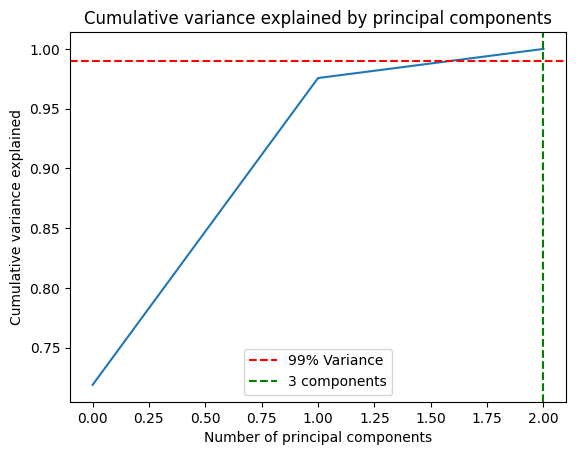

In [13]:
train_trajs = trajs['train_trajs'].sequence
train_trajs = train_trajs.reshape(-1, train_trajs.shape[-1])
# compute variance explained of each principal component
from sklearn.decomposition import PCA
pca = PCA(n_components=train_trajs.shape[1])
pca.fit(train_trajs)
variance_explained = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_explained)

# Find dimension explaining at least 99% variance
dim_99 = np.argmax(cumulative_variance >= 0.99) + 1

plt.plot(cumulative_variance)
plt.axhline(0.99, color='red', linestyle='--', label='99% Variance')
plt.axvline(dim_99-1, color='green', linestyle='--', label=f'{dim_99} components')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative variance explained')
plt.title('Cumulative variance explained by principal components')
plt.legend()
plt.show()


### 3.1 WMTask RNN Weight Matrix Analysis (wmtask only)

Load the source RNN from [wmtask](https://github.com/adamjeisen/wmtask) and plot singular values and eigenvalues of its recurrent weight matrix `W_hh`.

In [14]:
if DATA_SOURCE == "wmtask":
    from wmtask.loading import load_wmtask_model

    wmtask_model, wmtask_params = load_wmtask_model(
        WMTASK_PROJECT, WMTASK_NAME, model_to_load=WMTASK_MODEL_TO_LOAD
    )
    W_hh = wmtask_model.W_hh.detach().cpu().numpy()

    # Singular values
    U, s, Vh = np.linalg.svd(W_hh)
    # Eigenvalues (may be complex)
    eigvals = np.linalg.eigvals(W_hh)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Singular values (sorted descending, already from SVD)
    axes[0].semilogy(range(1, len(s) + 1), s, "o-", markersize=4)
    axes[0].set_xlabel("Index")
    axes[0].set_ylabel("Singular value")
    axes[0].set_title("Singular values of W_hh")
    axes[0].grid(True, alpha=0.3)

    # Eigenvalues in complex plane
    axes[1].scatter(eigvals.real, eigvals.imag, alpha=0.7, s=20)
    axes[1].axhline(0, color="k", linewidth=0.5)
    axes[1].axvline(0, color="k", linewidth=0.5)
    axes[1].set_xlabel("Re(λ)")
    axes[1].set_ylabel("Im(λ)")
    axes[1].set_title("Eigenvalues of W_hh")
    axes[1].set_aspect("equal")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Skipped: RNN weight analysis only applies when DATA_SOURCE='wmtask'")

Skipped: RNN weight analysis only applies when DATA_SOURCE='wmtask'


## 4. Check W&B for Completed Runs

Query W&B for runs that match the current sweep parameter combinations.
Only the remaining (not-yet-completed) combinations will be launched.

In [19]:
def _get_sweep_param_from_run(run, key):
    """Extract a sweep parameter value from a W&B run config.

    Keys are dot-separated Hydra paths like 'training.lightning.fnn_weight'.
    """
    parts = key.split('.')
    val = run.config
    for p in parts:
        if not isinstance(val, dict) or p not in val:
            return None
        val = val[p]
    return val


def _combo_matches_run(combo, run):
    """Check if a parameter combination matches a finished W&B run."""
    for key, target_val in combo.items():
        run_val = _get_sweep_param_from_run(run, key)
        if run_val is None:
            return False
        # Handle bool vs str comparisons
        if isinstance(target_val, bool):
            if bool(run_val) != target_val:
                return False
        elif isinstance(target_val, (int, float)):
            if abs(float(run_val) - float(target_val)) > 1e-10:
                return False
        else:
            if str(run_val) != str(target_val):
                return False
    return True


# Build all parameter combinations
sweep_keys = list(SWEEP_PARAMS.keys())
sweep_value_lists = [SWEEP_PARAMS[k] for k in sweep_keys]
all_combos = [
    dict(zip(sweep_keys, vals))
    for vals in itertools.product(*sweep_value_lists)
]

# Query W&B
api = wandb.Api()
try:
    run_filters = {"group": WANDB_GROUP} if WANDB_GROUP else None
    existing_runs = api.runs(WANDB_PROJECT_PATH, filters=run_filters)
    msg = f"Found {len(existing_runs)} total runs in {WANDB_PROJECT_PATH}"
    if WANDB_GROUP:
        msg += f" (group={WANDB_GROUP})"
    print(msg)
except Exception as e:
    print(f"Could not query project (may not exist yet): {e}")
    existing_runs = []

finished_runs = [r for r in existing_runs if r.state == 'finished']

already_done = []
remaining_combos = []
for combo in all_combos:
    if any(_combo_matches_run(combo, r) for r in finished_runs):
        already_done.append(combo)
    else:
        remaining_combos.append(combo)

print(f"\nAlready completed: {len(already_done)} / {len(all_combos)}")
print(f"Remaining to run:  {len(remaining_combos)}")

Found 0 total runs in JacobianODE/Lorenz_IND012_N1_D1_NormTrue__EncoderOnly (group=MLP_L_3_TANGENT_ENTROPY_SWEEP_N_SAMPLES_1024)

Already completed: 0 / 8
Remaining to run:  8


## 5. Launch Hydra Grid Sweep

Uses Hydra `--multirun` with the SLURM launcher to submit one job per
parameter combination. The `overrides` list from Section 2 is the
**single source of truth** — the sweep command simply appends the swept
parameters (comma-separated) and W&B/SLURM settings.

> **Wait for all SLURM jobs to finish** before proceeding to Section 7.

In [20]:
# ----------------------------------------------------------------
# Build the Hydra --multirun sweep command
# ----------------------------------------------------------------
ENTRY_POINT = "python -m JacobianODE.encoder_only.run_encoder"

if remaining_combos:
    n_remaining = len(remaining_combos)
    use_subset_sweep = n_remaining < n_combos

    wandb_overrides = [
        f"wandb_entity={WANDB_ENTITY}",
        f"wandb_project={WANDB_PROJECT}",
        "slurm=default",
    ]
    if WANDB_GROUP:
        wandb_overrides.append(f"wandb_group={WANDB_GROUP}")

    if use_subset_sweep:
        # One command per remaining combo — only run the missing combinations
        sweep_cmds = []
        for combo in remaining_combos:
            combo_overrides = [
                f"++{key}={str(val).lower() if isinstance(val, bool) else val}"
                for key, val in combo.items()
            ]
            sweep_overrides = overrides.copy() + combo_overrides + wandb_overrides
            sweep_cmds.append(f"{ENTRY_POINT} --multirun " + " ".join(sweep_overrides))
        print(f"Sweep command ({n_remaining} job(s), subset):")
        for i, cmd in enumerate(sweep_cmds):
            print(f"  [{i+1}] {cmd[:120]}...")
    else:
        # Full grid: Hydra --multirun creates the full grid from comma-separated values
        sweep_overrides = overrides.copy()
        for key, vals in SWEEP_PARAMS.items():
            val_str = ",".join(
                str(v).lower() if isinstance(v, bool) else str(v)
                for v in vals
            )
            sweep_overrides.append(f"++{key}={val_str}")
        sweep_overrides += wandb_overrides
        sweep_cmd = f"{ENTRY_POINT} --multirun " + " ".join(sweep_overrides)
        sweep_cmds = [sweep_cmd]
        print(f"Sweep command ({n_combos} jobs):")
        print(sweep_cmd)

if not remaining_combos:
    sweep_cmd = None
    sweep_cmds = []
    print("No sweep to launch — all runs already completed.")

Sweep command (8 jobs):
python -m JacobianODE.encoder_only.run_encoder --multirun model=mlp ++model.encoder.n_latent=3 ++model.use_same_state_decoder=true ++model.use_next_state_decoder=true ++model.decoder_hidden_dim=128 ++model.decoder_n_layers=2 ++model.next_state_burn_in=0 ++model.k_steps_ahead=10 ++model.n_obs_pred=3 ++model.encoder.hidden_dim=256 ++model.encoder.n_layers=3 ++model.encoder.dropout=0.1 ++training.batch_size=32 ++training.lightning.optimizer_kwargs.lr=0.0001 ++training.lightning.fnn_use_pca=True ++training.lightning.fnn_n_samples=1024 ++training.lightning.fnn_normalize=True ++training.lightning.fnn_elementwise_regularization=True ++training.lightning.fnn_sparsify=True ++training.lightning.jacobian_nuclear_n_samples=None ++training.lightning.tangent_entropy_n_samples=1024 ++training.lightning.tangent_entropy_mode=quadratic ++training.trainer_params.max_epochs=150 ++training.trainer_params.limit_train_batches=200 ++training.early_stopping.early_stopping_patience=2 ++t

In [21]:
# Pre-create directories so SLURM jobs skip os.makedirs entirely (avoids NFS hangs).
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "dysts_data"), exist_ok=True)
print(f"Ensured directories exist:\n  {SAVE_DIR}\n  {os.path.join(SAVE_DIR, 'dysts_data')}")

Ensured directories exist:
  /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/encoder_runs
  /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/encoder_runs/dysts_data


In [22]:
# Launch the sweep (submits SLURM jobs).
if sweep_cmds:
    if len(sweep_cmds) > 1:
        print(f"Starting {len(sweep_cmds)} commands in parallel...")
    procs = [subprocess.Popen(cmd, shell=True) for cmd in sweep_cmds]
    for i, p in enumerate(procs):
        p.wait()
        if p.returncode != 0 and len(procs) > 1:
            print(f"Command {i + 1}/{len(procs)} exited with code {p.returncode}")
    print("Sweep complete.")
else:
    print("No sweep to launch — all runs already completed.")

Sweep output dir : multirun/2026-03-18/18-17-35-927887
[2026-03-18 18:17:36,072][HYDRA] Submitit 'slurm' sweep output dir : multirun/2026-03-18/18-17-35-927887
[2026-03-18 18:17:36,077][HYDRA] 	#0 : model=mlp ++model.encoder.n_latent=3 ++model.use_same_state_decoder=True ++model.use_next_state_decoder=True ++model.decoder_hidden_dim=128 ++model.decoder_n_layers=2 ++model.next_state_burn_in=0 ++model.k_steps_ahead=10 ++model.n_obs_pred=3 ++model.encoder.hidden_dim=256 ++model.encoder.n_layers=3 ++model.encoder.dropout=0.1 ++training.batch_size=32 ++training.lightning.optimizer_kwargs.lr=0.0001 ++training.lightning.fnn_use_pca=True ++training.lightning.fnn_n_samples=1024 ++training.lightning.fnn_normalize=True ++training.lightning.fnn_elementwise_regularization=True ++training.lightning.fnn_sparsify=True ++training.lightning.jacobian_nuclear_n_samples=None ++training.lightning.tangent_entropy_n_samples=1024 ++training.lightning.tangent_entropy_mode=quadratic ++training.trainer_params.max

## 6. Collect W&B Runs

After all jobs finish, re-query W&B to verify all runs completed successfully.
Crashed/failed runs are flagged.

In [23]:
api = wandb.Api()
run_filters = {"group": WANDB_GROUP} if WANDB_GROUP else None
all_runs = api.runs(WANDB_PROJECT_PATH, filters=run_filters)
msg = f"Found {len(all_runs)} total runs in {WANDB_PROJECT_PATH}"
if WANDB_GROUP:
    msg += f" (group={WANDB_GROUP})"
print(msg)

# Flag crashed/failed runs
for run in all_runs:
    if run.state in ('crashed', 'failed'):
        print(f"  CRASHED/FAILED: {run.id} ({run.name}) — state={run.state}")

# Check completeness
finished_runs = [r for r in all_runs if r.state == 'finished']
completed_combos = []
missing_combos = []
for combo in all_combos:
    if any(_combo_matches_run(combo, r) for r in finished_runs):
        completed_combos.append(combo)
    else:
        missing_combos.append(combo)

print(f"\nCompleted: {len(completed_combos)} / {len(all_combos)}")
if missing_combos:
    print(f"MISSING {len(missing_combos)} combinations — re-run Section 5 to retry.")
    for combo in missing_combos[:5]:
        print(f"  {combo}")
    if len(missing_combos) > 5:
        print(f"  ... and {len(missing_combos) - 5} more")
else:
    print("All combinations completed successfully!")

Found 8 total runs in JacobianODE/Lorenz_IND012_N1_D1_NormTrue__EncoderOnly (group=MLP_L_3_TANGENT_ENTROPY_SWEEP_N_SAMPLES_1024)

Completed: 8 / 8
All combinations completed successfully!


## 7. Analyse Sweep Results

In [26]:
# ----------------------------------------------------------------
# Build results DataFrame from finished W&B runs
# ----------------------------------------------------------------
records = []
for r in finished_runs:
    # Check this run matches one of our sweep combos
    if not any(_combo_matches_run(combo, r) for combo in all_combos):
        continue

    rec = {}
    # Extract sweep parameters
    for key in sweep_keys:
        short_name = key.split('.')[-1]  # e.g. 'fnn_weight'
        rec[short_name] = _get_sweep_param_from_run(r, key)

    # Extract metrics
    rec['val_same_loss']    = r.summary.get('val/same_state_loss', float('nan'))
    rec['val_next_loss']    = r.summary.get('val/next_state_loss', float('nan'))
    rec['val_fnn_loss']     = r.summary.get('val/fnn_loss', float('nan'))
    rec['val_amp_loss']     = r.summary.get('val/amplification_loss', float('nan'))
    rec['latent_util']      = r.summary.get('val/latent_utilization', float('nan'))
    rec['val_total_loss']   = r.summary.get('val/total_loss', float('nan'))
    rec['run_name']         = r.name
    rec['run_id']           = r.id
    records.append(rec)

# df = pd.DataFrame(records).sort_values('val_same_loss')
df = pd.DataFrame(records).sort_values('val_next_loss')
print(f"{len(df)} finished runs in results")
df.head(10)

8 finished runs in results


,fnn_weight,amplification_weight,decov_weight,jacobian_nuclear_weight,tangent_entropy_weight,val_same_loss,val_next_loss,val_fnn_loss,val_amp_loss,latent_util,val_total_loss,run_name,run_id
4,0,1,0,0,0.00100,0.000412,0.001299,NaN,0.001357,0.459624,0.003451,Lorenz__MLPSequenceEncoder__n_latent_3__same__...,lz94uk8w
2,0,1,0,0,0.00001,0.000328,0.001304,NaN,0.001336,0.517096,0.002974,Lorenz__MLPSequenceEncoder__n_latent_3__same__...,bzcn8i7s
0,0,1,0,0,0.00010,0.000345,0.001333,NaN,0.001342,0.513761,0.003069,Lorenz__MLPSequenceEncoder__n_latent_3__same__...,hsys8w0x
1,0,1,0,0,0.01000,0.000536,0.001465,NaN,0.001678,0.492021,0.004600,Lorenz__MLPSequenceEncoder__n_latent_3__same__...,nyp3ga2j
3,0,1,0,0,0.00000,0.000515,0.001777,NaN,0.001348,0.646216,0.003640,Lorenz__MLPSequenceEncoder__n_latent_3__same__...,lrbmare2
5,0,1,0,0,0.10000,0.001008,0.002071,NaN,0.002265,0.640742,0.006520,Lorenz__MLPSequenceEncoder__n_latent_3__same__...,ax3k1n4w
6,0,1,0,0,1.00000,0.005023,0.005057,NaN,0.002851,0.606192,0.015996,Lorenz__MLPSequenceEncoder__n_latent_3__same__...,udr4usqq
7,0,1,0,0,10.00000,0.086772,0.111965,NaN,0.007590,0.910721,0.436866,Lorenz__MLPSequenceEncoder__n_latent_3__same__...,5urzn8ys


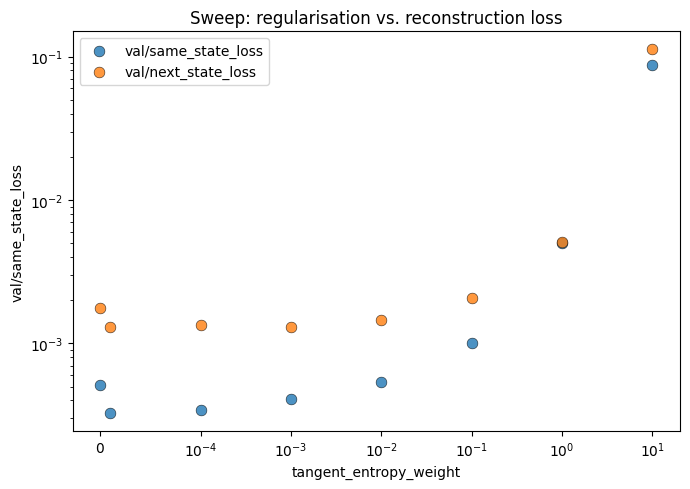

In [27]:
# ---- Scatter: fnn_weight vs val_same_state_loss, coloured by amplification_weight ----
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    # df['fnn_weight'],
    # df['n_latent'],
    df['tangent_entropy_weight'],
    df['val_same_loss'],
    c="C0",
    label="val/same_state_loss",
    s=60, alpha=0.8, edgecolors='k', linewidths=0.4,
)
sc = ax.scatter(
    # df['fnn_weight'],
    # df['n_latent'],
    df['tangent_entropy_weight'],
    df['val_next_loss'],
    c="C1",
    label="val/next_state_loss",
    s=60, alpha=0.8, edgecolors='k', linewidths=0.4,
)
# plt.colorbar(sc, ax=ax, label='fnn_weight')
plt.legend()
ax.set_xscale('symlog', linthresh=1e-4)
ax.set_yscale('log')
# ax.set_xlabel('fnn_weight')
# ax.set_xlabel('n_latent')
ax.set_xlabel('tangent_entropy_weight')
ax.set_ylabel('val/same_state_loss')
ax.set_title('Sweep: regularisation vs. reconstruction loss')
plt.tight_layout()
plt.show()

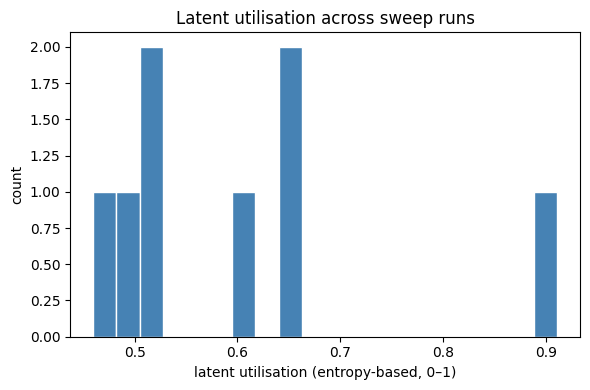

In [28]:
# ---- Latent utilisation distribution ----
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df['latent_util'].dropna(), bins=20, color='steelblue', edgecolor='white')
ax.set_xlabel('latent utilisation (entropy-based, 0\u20131)')
ax.set_ylabel('count')
ax.set_title('Latent utilisation across sweep runs')
plt.tight_layout()
plt.show()

In [29]:
# ---- Best run summary ----
best = df.iloc[0]
# best = df[df['fnn_weight'] == 1e-1].iloc[0]
print('Best run (lowest val/same_state_loss):')
for col in df.columns:
    print(f'  {col:40s}: {best[col]}')

Best run (lowest val/same_state_loss):
  fnn_weight                              : 0
  amplification_weight                    : 1
  decov_weight                            : 0
  jacobian_nuclear_weight                 : 0
  tangent_entropy_weight                  : 0.001
  val_same_loss                           : 0.00041230645729228854
  val_next_loss                           : 0.0012986187357455492
  val_fnn_loss                            : nan
  val_amp_loss                            : 0.001356972148641944
  latent_util                             : 0.4596240222454071
  val_total_loss                          : 0.0034509925171732903
  run_name                                : Lorenz__MLPSequenceEncoder__n_latent_3__same__next__amplification_weight_1__tangent_entropy_weight_0.001__run_0
  run_id                                  : lz94uk8w


## 8. Tangent Space Variance (Best Encoder)

Compute the variance explained by each dimension of the encoder tangent space for the best run (lowest val/same_state_loss), following the methodology from the Tangent Spaces notebook.

In [30]:
# -----------------------------------------------------------------------------
# Variance explained by each dimension of the encoder tangent space
# (Based on 2026-03-09 - Tangent Spaces.ipynb)
# -----------------------------------------------------------------------------
# Requires: df, best, trajs, WANDB_PROJECT_PATH, SAVE_DIR from Sections 3 and 7

from JacobianODE.encoder_only.pretrained import load_pretrained_encoder

SORT = True

# Load the best encoder (lowest val/same_state_loss)
adapter, _, _ = load_pretrained_encoder(
    project=WANDB_PROJECT_PATH,
    run_id=best["run_id"],
    save_dir=SAVE_DIR,
    freeze=True,
    verbose=True,
)
adapter.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
adapter.to(device)

# Training sequences: (n_sequences, seq_length, n_obs)
train_seq = trajs["train_trajs"].sequence.to(device)
n_obs = train_seq.shape[-1]
n_latent = adapter.n_latent


def encode_point(x):
    """Map single observation (D,) to latent (n_latent,)."""
    return adapter.encoder(x.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)


# Consecutive pairs for dz
x_t = train_seq[:, :-1, :].reshape(-1, n_obs)
print(f"x_t.shape: {x_t.shape}")
x_next = train_seq[:, 1:, :].reshape(-1, n_obs)
N_diff = min(5000, x_t.shape[0])
x_t = x_t[:N_diff]
x_next = x_next[:N_diff]
print(f"x_t.shape after reshape: {x_t.shape}, using {N_diff} consecutive pairs")
with torch.no_grad():
    z_t = adapter.encoder(x_t.unsqueeze(1)).squeeze(1)
    z_next = adapter.encoder(x_next.unsqueeze(1)).squeeze(1)
    dz = z_next - z_t
    print(f"dz.shape: {dz.shape}")
    jacobians_t = torch.func.vmap(torch.func.jacfwd(encode_point))(x_t)
    U, S, V = torch.linalg.svd(jacobians_t, full_matrices=True)

# Project dz onto local tangent basis U
print(f"dz.shape: {dz.shape}")
print(f"U.shape: {U.shape}")
tangent_projection = (dz.unsqueeze(1) @ U).squeeze(1)

# Variance explained per dimension
with torch.no_grad():
    squared_projections = tangent_projection**2
    if SORT:
        squared_projections_sorted, _ = torch.sort(squared_projections, dim=-1, descending=True)
        variance_per_dim = squared_projections_sorted.mean(dim=0)
    else:
        variance_per_dim = squared_projections.mean(dim=0)
    total_variance = variance_per_dim.sum()
    variance_explained = variance_per_dim / total_variance
    cumulative_variance = torch.cumsum(variance_explained, dim=0)

print(f"\nTangent space variance (best encoder, fnn_weight={best.get('fnn_weight', 'N/A')}):")
print(f"{'Dimension':<10} | {'Variance Explained':<20} | {'Cumulative'}")
print("-" * 45)
for i in range(len(variance_explained)):
    val = variance_explained[i].item() * 100
    cum = cumulative_variance[i].item() * 100
    print(f"Dim {i+1:<5} | {val:>17.4f}% | {cum:>10.4f}%")

Loading checkpoint epoch=62-step=3150.ckpt...
x_t.shape: torch.Size([26378, 3])
x_t.shape after reshape: torch.Size([5000, 3]), using 5000 consecutive pairs
dz.shape: torch.Size([5000, 3])
dz.shape: torch.Size([5000, 3])
U.shape: torch.Size([5000, 3, 3])

Tangent space variance (best encoder, fnn_weight=0):
Dimension  | Variance Explained   | Cumulative
---------------------------------------------
Dim 1     |           83.2929% |    83.2929%
Dim 2     |           14.4597% |    97.7526%
Dim 3     |            2.2474% |   100.0000%


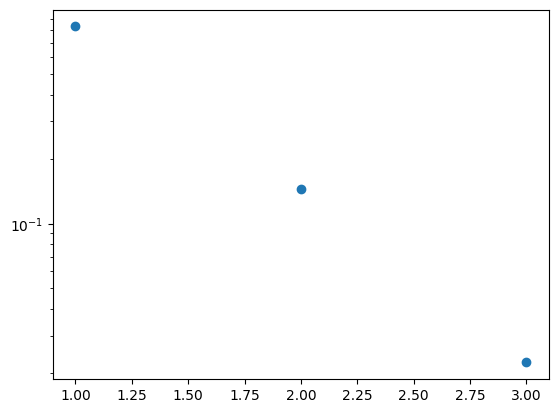

In [31]:
plt.scatter(np.arange(len(variance_explained)) + 1, variance_explained.cpu().numpy())
plt.yscale('log')
plt.show()

In [107]:
torch.manual_seed(42)
proj_mat = torch.randn(11, 3).to(device)

In [108]:
U_proj = U.transpose(1, 2) @ proj_mat
tangent_projection_proj = (dz.unsqueeze(1) @ proj_mat).squeeze(1)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (15000x3 and 11x3)

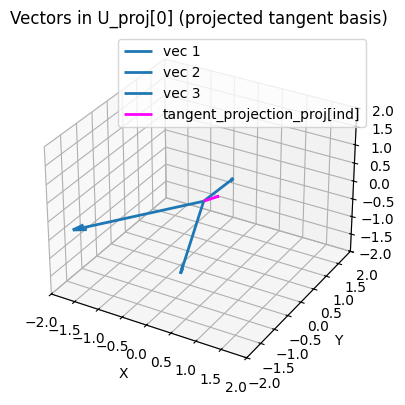

In [109]:
# Plot the vectors in U_proj[0] as 3D vectors from the origin
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

origin = [0, 0, 0]

# U_proj[0] is shape (3, 3): 3 vectors of dimension 3 each, so loop over columns
N_VECS = 3
ind = 200
for i in range(N_VECS):
    vec = U_proj[ind][i]
    ax.quiver(
        origin[0], origin[1], origin[2],
        vec[0].item(), vec[1].item(), vec[2].item(),
        arrow_length_ratio=0.1, linewidth=2, label=f'vec {i+1}'
    )

# plot the vector tangent_projection_proj[ind]
ax.quiver(
    origin[0], origin[1], origin[2],
    tangent_projection_proj[ind][0].item(), tangent_projection_proj[ind][1].item(), tangent_projection_proj[ind][2].item(),
    arrow_length_ratio=0.1, linewidth=2, label=f'tangent_projection_proj[ind]', color='magenta'
)

ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([-2, 2])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Vectors in U_proj[0] (projected tangent basis)')
ax.legend()
plt.tight_layout()
plt.show()

In [110]:
# -----------------------------------------------------------------------------
# Variance explained by each dimension of the encoder tangent space
# (Using Spatial Perturbations / Nearest Neighbors)
# -----------------------------------------------------------------------------
# Requires: df, best, trajs, WANDB_PROJECT_PATH, SAVE_DIR from Sections 3 and 7

import torch
from JacobianODE.encoder_only.pretrained import load_pretrained_encoder

SORT = True
K_NEIGHBORS = 10  # Number of spatial neighbors to sample to map the full geometry

# Load the best encoder (lowest val/same_state_loss)
adapter, _, _ = load_pretrained_encoder(
    project=WANDB_PROJECT_PATH,
    run_id=best["run_id"],
    save_dir=SAVE_DIR,
    freeze=True,
    verbose=True,
)
adapter.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
adapter.to(device)

# Training sequences: (n_sequences, seq_length, n_obs)
train_seq = trajs["train_trajs"].sequence.to(device)
n_obs = train_seq.shape[-1]
n_latent = adapter.n_latent

def encode_point(x):
    """Map single observation (D,) to latent (n_latent,)."""
    return adapter.encoder(x.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)

# Flatten and subsample points for evaluation (we don't need temporal pairs anymore)
x_t = train_seq.reshape(-1, n_obs)
print(f"Total x_t.shape: {x_t.shape}")
N_diff = min(10000, x_t.shape[0])
x_t = x_t[:N_diff]
print(f"x_t.shape after reshape: {x_t.shape}, finding {K_NEIGHBORS} spatial neighbors")

with torch.no_grad():
    # 1. Encode the base points into the latent space
    z_t = adapter.encoder(x_t.unsqueeze(1)).squeeze(1)  # (N_diff, n_latent)
    
    # 2. Find K nearest neighbors using exact pairwise distances (CUDA accelerated)
    dists = torch.cdist(z_t, z_t)
    # topk with largest=False gets the smallest distances. 
    # We pull K+1 to exclude the point itself (which has a distance of 0)
    _, indices = torch.topk(dists, K_NEIGHBORS + 1, largest=False, dim=1)
    neighbor_idx = indices[:, 1:]  # (N_diff, K_NEIGHBORS)
    
    # 3. Extract neighbor vectors and compute spatial secants (dz)
    z_neighbors = z_t[neighbor_idx]  # (N_diff, K_NEIGHBORS, n_latent)
    dz = z_neighbors - z_t.unsqueeze(1)  # (N_diff, K_NEIGHBORS, n_latent)
    print(f"dz.shape (spatial perturbations): {dz.shape}")
    
    # 4. Compute the encoder Jacobian and its SVD at the base points
    jacobians_t = torch.func.vmap(torch.func.jacfwd(encode_point))(x_t)
    U, S, V = torch.linalg.svd(jacobians_t, full_matrices=True)

# Project the K spatial dz vectors onto the local tangent basis U
print(f"U.shape: {U.shape}")
# dz is (N, K, n_latent), U is (N, n_latent, n_latent)
# PyTorch matmul broadcast cleanly maps this to (N, K, n_latent)
tangent_projection = dz @ U

# Variance explained per dimension
with torch.no_grad():
    squared_projections = tangent_projection**2  # (N_diff, K_NEIGHBORS, n_latent)
    
    # Average the squared projections across the K local spatial neighbors first
    local_variance = squared_projections.mean(dim=1)  # (N_diff, n_latent)
    
    if SORT:
        # Sort dimensions descending per local point to prevent curvature smearing
        local_variance_sorted, _ = torch.sort(local_variance, dim=-1, descending=True)
        variance_per_dim = local_variance_sorted.mean(dim=0)
    else:
        variance_per_dim = local_variance.mean(dim=0)
        
    total_variance = variance_per_dim.sum()
    variance_explained = variance_per_dim / total_variance
    cumulative_variance = torch.cumsum(variance_explained, dim=0)

print(f"\nTangent space spatial variance (best encoder, fnn_weight={best.get('fnn_weight', 'N/A')}):")
print(f"{'Dimension':<10} | {'Variance Explained':<20} | {'Cumulative'}")
print("-" * 45)
for i in range(len(variance_explained)):
    val = variance_explained[i].item() * 100
    cum = cumulative_variance[i].item() * 100
    print(f"Dim {i+1:<5} | {val:>17.4f}% | {cum:>10.4f}%")

Loading checkpoint epoch=46-step=2350.ckpt...
Total x_t.shape: torch.Size([26180, 11])
x_t.shape after reshape: torch.Size([10000, 11]), finding 10 spatial neighbors
dz.shape (spatial perturbations): torch.Size([10000, 10, 3])
U.shape: torch.Size([10000, 3, 3])

Tangent space spatial variance (best encoder, fnn_weight=0):
Dimension  | Variance Explained   | Cumulative
---------------------------------------------
Dim 1     |           61.7669% |    61.7669%
Dim 2     |           37.7513% |    99.5182%
Dim 3     |            0.4818% |   100.0000%


## Going by next state

In [111]:
# ---- Best run summary (based on val_next_loss) ----
best = df.loc[df['val_next_loss'].idxmin()]
print('Best run (lowest val/next_state_loss):')
for col in df.columns:
    print(f'  {col:40s}: {best[col]}')

Best run (lowest val/next_state_loss):
  fnn_weight                              : 0
  amplification_weight                    : 0
  decov_weight                            : 0
  n_latent                                : 3
  val_same_loss                           : 0.0006486409693025053
  val_next_loss                           : 0.002808128483593464
  val_fnn_loss                            : nan
  val_amp_loss                            : nan
  latent_util                             : 0.9824354648590088
  val_total_loss                          : 0.003456770209595561
  run_name                                : Lorenz__MLPSequenceEncoder__n_latent_3__same__next__run_0
  run_id                                  : o90cahci


In [112]:
# -----------------------------------------------------------------------------
# Variance explained by each dimension of the encoder tangent space
# (Based on 2026-03-09 - Tangent Spaces.ipynb)
# -----------------------------------------------------------------------------
# Requires: df, best, trajs, WANDB_PROJECT_PATH, SAVE_DIR from Sections 3 and 7

from JacobianODE.encoder_only.pretrained import load_pretrained_encoder

# Load the best encoder (lowest val/same_state_loss)
adapter, _, _ = load_pretrained_encoder(
    project=WANDB_PROJECT_PATH,
    run_id=best["run_id"],
    save_dir=SAVE_DIR,
    freeze=True,
    verbose=True,
)
adapter.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
adapter.to(device)

# Training sequences: (n_sequences, seq_length, n_obs)
train_seq = trajs["train_trajs"].sequence.to(device)
n_obs = train_seq.shape[-1]
n_latent = adapter.n_latent


def encode_point(x):
    """Map single observation (D,) to latent (n_latent,)."""
    return adapter.encoder(x.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)


# Consecutive pairs for dz
x_t = train_seq[:, :-1, :].reshape(-1, n_obs)
print(f"x_t.shape: {x_t.shape}")
x_next = train_seq[:, 1:, :].reshape(-1, n_obs)
N_diff = min(2000, x_t.shape[0])
x_t = x_t[:N_diff]
x_next = x_next[:N_diff]
print(f"x_t.shape after reshape: {x_t.shape}, using {N_diff} consecutive pairs")
with torch.no_grad():
    z_t = adapter.encoder(x_t.unsqueeze(1)).squeeze(1)
    z_next = adapter.encoder(x_next.unsqueeze(1)).squeeze(1)
    dz = z_next - z_t
    print(f"dz.shape: {dz.shape}")
    jacobians_t = torch.func.vmap(torch.func.jacfwd(encode_point))(x_t)
    U, S, V = torch.linalg.svd(jacobians_t, full_matrices=True)

# Project dz onto local tangent basis U
print(f"dz.shape: {dz.shape}")
print(f"U.shape: {U.shape}")
tangent_projection = (dz.unsqueeze(1) @ U).squeeze(1)

# Variance explained per dimension
with torch.no_grad():
    squared_projections = tangent_projection**2
    variance_per_dim = squared_projections.mean(dim=0)
    total_variance = variance_per_dim.sum()
    variance_explained = variance_per_dim / total_variance
    cumulative_variance = torch.cumsum(variance_explained, dim=0)

print(f"\nTangent space variance (best encoder, fnn_weight={best.get('fnn_weight', 'N/A')}):")
print(f"{'Dimension':<10} | {'Variance Explained':<20} | {'Cumulative'}")
print("-" * 45)
for i in range(len(variance_explained)):
    val = variance_explained[i].item() * 100
    cum = cumulative_variance[i].item() * 100
    print(f"Dim {i+1:<5} | {val:>17.4f}% | {cum:>10.4f}%")

Loading checkpoint epoch=46-step=2350.ckpt...
x_t.shape: torch.Size([26158, 11])
x_t.shape after reshape: torch.Size([2000, 11]), using 2000 consecutive pairs
dz.shape: torch.Size([2000, 3])
dz.shape: torch.Size([2000, 3])
U.shape: torch.Size([2000, 3, 3])

Tangent space variance (best encoder, fnn_weight=0):
Dimension  | Variance Explained   | Cumulative
---------------------------------------------
Dim 1     |           53.9461% |    53.9461%
Dim 2     |           45.8709% |    99.8170%
Dim 3     |            0.1830% |   100.0000%


In [52]:
# # -----------------------------------------------------------------------------
# # Variance explained by each active/inactive dimension of the input space
# # -----------------------------------------------------------------------------
# # Requires: df, best, trajs, WANDB_PROJECT_PATH, SAVE_DIR from Sections 3 and 7

# from JacobianODE.encoder_only.pretrained import load_pretrained_encoder

# # Load the best encoder (lowest val/same_state_loss)
# adapter, _, _ = load_pretrained_encoder(
#     project=WANDB_PROJECT_PATH,
#     run_id=best["run_id"],
#     save_dir=SAVE_DIR,
#     freeze=True,
#     verbose=True,
# )
# adapter.eval()

# device = "cuda" if torch.cuda.is_available() else "cpu"
# adapter.to(device)

# # Training sequences: (n_sequences, seq_length, n_obs)
# train_seq = trajs["train_trajs"].sequence.to(device)
# n_obs = train_seq.shape[-1]
# n_latent = adapter.n_latent


# def encode_point(x):
#     """Map single observation (D,) to latent (n_latent,)."""
#     return adapter.encoder(x.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)


# # Consecutive pairs for dx
# x_t = train_seq[:, :-1, :].reshape(-1, n_obs)
# print(f"x_t.shape: {x_t.shape}")
# x_next = train_seq[:, 1:, :].reshape(-1, n_obs)
# N_diff = min(2000, x_t.shape[0])
# x_t = x_t[:N_diff]
# x_next = x_next[:N_diff]
# print(f"x_t.shape after reshape: {x_t.shape}, using {N_diff} consecutive pairs")

# with torch.no_grad():
#     # Calculate the step in the observation space
#     dx = x_next - x_t
#     print(f"dx.shape: {dx.shape}")
    
#     jacobians_t = torch.func.vmap(torch.func.jacfwd(encode_point))(x_t)
#     # Note: PyTorch svd returns U, S, V^T. The third output is V^T.
#     U, S, V_T = torch.linalg.svd(jacobians_t, full_matrices=True)

# # Project dx onto the right singular vectors (the true V matrix)
# # We transpose V_T to get V, where the columns are the right singular vectors.
# V_true = V_T.transpose(-1, -2)
# input_projection = (dx.unsqueeze(1) @ V_true).squeeze(1)

# # Variance explained per dimension in the input space
# with torch.no_grad():
#     squared_projections = input_projection**2
#     variance_per_dim = squared_projections.mean(dim=0)
#     total_variance = variance_per_dim.sum()
#     variance_explained = variance_per_dim / total_variance
#     cumulative_variance = torch.cumsum(variance_explained, dim=0)

# print(f"\nInput space variance (best encoder, fnn_weight={best.get('fnn_weight', 'N/A')}):")
# print(f"{'Dimension':<10} | {'Variance Explained':<20} | {'Cumulative'}")
# print("-" * 45)
# for i in range(len(variance_explained)):
#     val = variance_explained[i].item() * 100
#     cum = cumulative_variance[i].item() * 100
#     print(f"Dim {i+1:<5} | {val:>17.4f}% | {cum:>10.4f}%")